# שלב 1 — יצירת דאטה סינטטי

בשלב הזה ניצור דאטה מלאכותי עבור הפרויקט.

כל דוגמה בדאטה תכלול:

1. תמונה של שעון דיגיטלי  
2. תמונה של שעון אנלוגי עם מחוגים  
3. תמונה של אותו שעון אנלוגי בלי מחוגים  
4. קובץ labels.csv עם השעה המתאימה לכל תמונה

In [1]:
import os
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt

## יצירת תיקיות

כאן ניצור את מבנה התיקיות של הדאטה:

- digital — תמונות של שעונים דיגיטליים
- analog_with_hands — שעונים אנלוגיים עם מחוגים
- analog_clean — שעונים אנלוגיים בלי מחוגים
- labels.csv — טבלת התוויות

In [4]:
BASE_DIR = Path("clock_project")
DATA_DIR = BASE_DIR / "data"

DIGITAL_DIR = DATA_DIR / "digital"
ANALOG_WITH_HANDS_DIR = DATA_DIR / "analog_with_hands"
ANALOG_CLEAN_DIR = DATA_DIR / "analog_clean"

for folder in [DIGITAL_DIR, ANALOG_WITH_HANDS_DIR, ANALOG_CLEAN_DIR]:
    folder.mkdir(parents=True, exist_ok=True)


## פונקציה ליצירת שעון דיגיטלי

הפונקציה מקבלת שעה, דקה ושנייה, ומחזירה תמונה של שעון דיגיטלי בפורמט:

HH:MM:SS

In [5]:
def create_digital_clock_image(hour, minute, second, image_size=224):
    img = Image.new("RGB", (image_size, image_size), color=(10, 10, 10))
    draw = ImageDraw.Draw(img)

    time_text = f"{hour:02d}:{minute:02d}:{second:02d}"

    try:
        font = ImageFont.truetype("arial.ttf", 40)
    except:
        font = ImageFont.load_default()

    bbox = draw.textbbox((0, 0), time_text, font=font)
    text_width = bbox[2] - bbox[0]
    text_height = bbox[3] - bbox[1]

    x = (image_size - text_width) // 2
    y = (image_size - text_height) // 2

    draw.rounded_rectangle(
        [20, 70, image_size - 20, 150],
        radius=12,
        fill=(0, 0, 0),
        outline=(40, 40, 40),
        width=3
    )

    draw.text((x, y), time_text, fill=(0, 255, 120), font=font)

    return img

## פונקציות ליצירת שעון אנלוגי

כאן ניצור שעון אנלוגי.

נשתמש בשלוש פונקציות:

1. ציור פני השעון  
2. ציור מחוג לפי זווית  
3. יצירת תמונה מלאה של שעון אנלוגי, עם או בלי מחוגים

In [6]:
def draw_clock_face(draw, center, radius):
    cx, cy = center

    draw.ellipse(
        [cx - radius, cy - radius, cx + radius, cy + radius],
        outline=(20, 20, 20),
        width=4,
        fill=(245, 245, 240)
    )

    for i in range(60):
        angle = math.radians(i * 6 - 90)

        if i % 5 == 0:
            inner = radius - 15
            width = 3
        else:
            inner = radius - 8
            width = 1

        x1 = cx + inner * math.cos(angle)
        y1 = cy + inner * math.sin(angle)
        x2 = cx + radius * math.cos(angle)
        y2 = cy + radius * math.sin(angle)

        draw.line([x1, y1, x2, y2], fill=(30, 30, 30), width=width)


def draw_hand(draw, center, angle_deg, length, color, width):
    cx, cy = center
    angle = math.radians(angle_deg - 90)

    x = cx + length * math.cos(angle)
    y = cy + length * math.sin(angle)

    draw.line([cx, cy, x, y], fill=color, width=width)


def create_analog_clock_image(hour, minute, second, image_size=224, with_hands=True):
    img = Image.new("RGB", (image_size, image_size), color=(230, 230, 225))
    draw = ImageDraw.Draw(img)

    center = (image_size // 2, image_size // 2)
    radius = 90

    draw_clock_face(draw, center, radius)

    if with_hands:
        hour_angle = ((hour % 12) + minute / 60) * 30
        minute_angle = (minute + second / 60) * 6
        second_angle = second * 6

        draw_hand(draw, center, hour_angle, 45, (20, 20, 20), 6)
        draw_hand(draw, center, minute_angle, 65, (20, 20, 20), 4)
        draw_hand(draw, center, second_angle, 75, (200, 0, 0), 2)

        cx, cy = center
        draw.ellipse([cx - 5, cy - 5, cx + 5, cy + 5], fill=(20, 20, 20))

    return img

בדיקה על דוגמה אחת

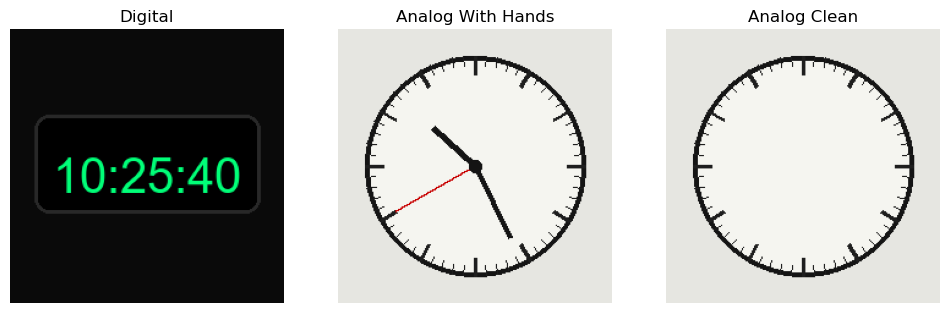

In [7]:
hour, minute, second = 10, 25, 40

digital_img = create_digital_clock_image(hour, minute, second)
analog_hands_img = create_analog_clock_image(hour, minute, second, with_hands=True)
analog_clean_img = create_analog_clock_image(hour, minute, second, with_hands=False)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(digital_img)
plt.title("Digital")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(analog_hands_img)
plt.title("Analog With Hands")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(analog_clean_img)
plt.title("Analog Clean")
plt.axis("off")

plt.show()

יצירת הדאטה המלא- יוצרים 1000 דוגמאות כאלה

In [10]:
NUM_SAMPLES = 1000

records = []

for sample_id in range(NUM_SAMPLES):
    hour = random.randint(0, 23)
    minute = random.randint(0, 59)
    second = random.randint(0, 59)

    digital_img = create_digital_clock_image(hour, minute, second)
    analog_hands_img = create_analog_clock_image(hour, minute, second, with_hands=True)
    analog_clean_img = create_analog_clock_image(hour, minute, second, with_hands=False)

    digital_path = DIGITAL_DIR / f"digital_{sample_id:05d}.png"
    analog_hands_path = ANALOG_WITH_HANDS_DIR / f"analog_hands_{sample_id:05d}.png"
    analog_clean_path = ANALOG_CLEAN_DIR / f"analog_clean_{sample_id:05d}.png"

    digital_img.save(digital_path)
    analog_hands_img.save(analog_hands_path)
    analog_clean_img.save(analog_clean_path)

    records.append({
        "sample_id": sample_id,
        "digital_image_path": str(digital_path),
        "analog_with_hands_path": str(analog_hands_path),
        "analog_clean_path": str(analog_clean_path),
        "hour": hour,
        "minute": minute,
        "second": second
    })

labels_df = pd.DataFrame(records)

LABELS_PATH = DATA_DIR / "labels.csv"
labels_df.to_csv(LABELS_PATH, index=False)

print("Number of samples:", len(labels_df))
labels_df.head()

Number of samples: 1000


,sample_id,digital_image_path,analog_with_hands_path,analog_clean_path,hour,minute,second
0,0,clock_project\data\digital\digital_00000.png,clock_project\data\analog_with_hands\analog_ha...,clock_project\data\analog_clean\analog_clean_0...,4,11,10
1,1,clock_project\data\digital\digital_00001.png,clock_project\data\analog_with_hands\analog_ha...,clock_project\data\analog_clean\analog_clean_0...,23,55,46
2,2,clock_project\data\digital\digital_00002.png,clock_project\data\analog_with_hands\analog_ha...,clock_project\data\analog_clean\analog_clean_0...,17,53,50
3,3,clock_project\data\digital\digital_00003.png,clock_project\data\analog_with_hands\analog_ha...,clock_project\data\analog_clean\analog_clean_0...,3,52,59
4,4,clock_project\data\digital\digital_00004.png,clock_project\data\analog_with_hands\analog_ha...,clock_project\data\analog_clean\analog_clean_0...,17,17,6


Total samples: 1000
   sample_id                            digital_image_path  \
0          0  clock_project\data\digital\digital_00000.png   
1          1  clock_project\data\digital\digital_00001.png   
2          2  clock_project\data\digital\digital_00002.png   
3          3  clock_project\data\digital\digital_00003.png   
4          4  clock_project\data\digital\digital_00004.png   

                              analog_with_hands_path  \
0  clock_project\data\analog_with_hands\analog_ha...   
1  clock_project\data\analog_with_hands\analog_ha...   
2  clock_project\data\analog_with_hands\analog_ha...   
3  clock_project\data\analog_with_hands\analog_ha...   
4  clock_project\data\analog_with_hands\analog_ha...   

                                   analog_clean_path  hour  minute  second  
0  clock_project\data\analog_clean\analog_clean_0...     4      11      10  
1  clock_project\data\analog_clean\analog_clean_0...    23      55      46  
2  clock_project\data\analog_clean\anal

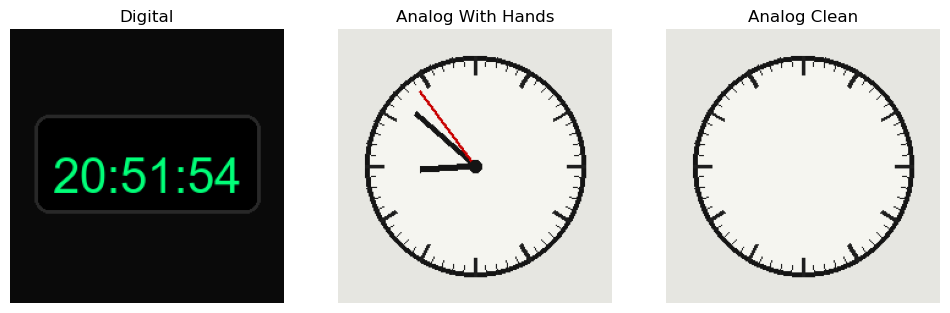

In [11]:
df = pd.read_csv(DATA_DIR / "labels.csv")

print("Total samples:", len(df))
print(df.head())

sample = df.sample(1).iloc[0]

digital_img = Image.open(sample["digital_image_path"])
analog_hands_img = Image.open(sample["analog_with_hands_path"])
analog_clean_img = Image.open(sample["analog_clean_path"])

print(f'Time: {sample["hour"]:02d}:{sample["minute"]:02d}:{sample["second"]:02d}')

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(digital_img)
plt.title("Digital")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(analog_hands_img)
plt.title("Analog With Hands")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(analog_clean_img)
plt.title("Analog Clean")
plt.axis("off")

plt.show()